<a href="https://colab.research.google.com/github/Atom-thor/PUC2026MVP-Machine-Learning-Analytics/blob/main/MVP_ML_Analytics_20261_Jo%C3%A3o_B_A_Morais.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** _João Bruno de Almeida Morais_  
**Matrícula:** _4052026000080_  
**Data:** _20/06/2026_  
**Dataset:** _Arrhythmia - https://archive.ics.uci.edu/dataset/5/arrhythmia_  
**Tipo de problema:** _Classificação_

# 1. Definição do problema

## 1.1 Descrição do problema

Doenças cardíacas são uma das principais causas de óbito no mundo, sendo a arritmia uma condição de alto risco para o bem estar e saúde do paciente. Eletrocardiogramas são o principal método de análise e diagnóstico de condições cardíacas, e modelos de machine learning são úteis no auxílio do diagnóstico e classificação de tipo de condição do paciente, reduzindo variações de julgamento médico e identificação de padrões que possam ser subjetivos ou difíceis de serem detectados por profissionais de saúde, como cardiologistas e equipes de triagem.

O presente trabalho utiliza o dataset Arrhythmia do repositório UCI Machine Learning, e tem como objetivo o desenvolvimento de um modelo classificatório capaz de distinguir pacientes com batimento cardíaco normal de pacientes com algum tipo de arritmia, priorizando um baixo índice de falsos negativos, desejável em contextos de triagem clínica, visto que deixar de identificar uma condição é mais custoso ao bem estar do paciente do que um falso alarme.

## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  
> _O objetivo do MVP é construir e avaliar modelos de Machine Learning para classificação de pacientes com arritmia a partir de atributos de leitura de eletrocardiogramas, comparando uma abordagem baseline com modelos candidados e discutindo suas limitações._


## 1.3 Tipo de problema

**Tipo escolhido:** _Classificação multivariada_  
**Justificativa:** _O dataset escolhido objetiva determinar se um paciente possui arritmia dentre os com ritmo cardíaco normal a partir de 279 atributos fisiológicos e de leitura de eletrocardiograma._


## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. _Os atributos extraídos do eletrocardiograma (ângulos, durações de onda e amplitudes por canal) contêm sinal suficiente para discriminar entre pacientes normais e arrítmicos._
2. _A ausência de valores nos atributos é aleatória e não relacionada a classe alvo._
3. _As classes com poucas instâncias não permitem generalização confiável._
4. _Falsos negativos são clinicamente mais custosos que falsos positivos._
5. _A alta dimensionalidade do dataset (279 atributos para 452 amostras) torna os modelos propensos a overfitting, especialmente os mais sensíveis à maldição da dimensionalidade._

**Critérios de sucesso:**

Métrica principal: Recall

Justificativa: Classificações falso negativos para arritmia podem resultar em diagnóstico e tratamento tardio para pacientes.

Resultado esperado: Superar o baseline em 10 pontos percentuais no recall para a classe positiva, com um valor mínimo desejável superior a 0.70, e uma área sob a curva de precisão e recall (PR-AUC) superior ao baseline.

Restrição prática:

Os modelos avaliados devem manter custo computacional baixo o suficiente para viabilizar inferência em tempo real em equipamentos médicos com poder de processamento restrito (ex.: monitores de beira de leito, dispositivos portáteis de ECG), o que favorece modelos mais simples e leves frente a alternativas computacionalmente mais custosas, ainda que estas apresentem desempenho marginalmente superior. Interpretabilidade do modelo também é desejável, dado o contexto clínico de apoio à decisão.


# 2. Ambiente, bibliotecas e reprodutibilidade

In [1]:
# Setup básico e reprodutibilidade
import time
import sys
import warnings

import requests

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    recall_score
    , average_precision_score
    ,classification_report
    ,ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

SEED = 1000
np.random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 1000


## 2.1 Dependências adicionais

Para esse notebook, foi necessário o uso da biblioteca Optuna para otimização automatizada de hiperparâmetros.


In [2]:
!pip install optuna

import optuna

# Sampler do optuna foi parametrizado para ser o valor da seed definida no início
Sampler = optuna.samplers.TPESampler(seed=SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 8.7 MB/s eta 0:00:00


## 2.2 Funções auxiliares



In [3]:
def evaluate_classification(y_true, y_pred, proba=None):
    """Calcula métricas básicas para classificação."""
    results = {
        "Recall": recall_score(y_true, y_pred, pos_label=1)
    }

    # PR AUC é mais direto para classificação binária com probabilidades.
    try:
        if proba is not None and proba.shape[1] == 2:
            results["pr_auc"] = average_precision_score(y_true, proba[:, 1], pos_label=1)
        else:
            results["pr_auc"] = np.nan
    except Exception:
        results["pr_auc"] = np.nan

    return results


def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T


def make_objective(
    model_class,
    param_space,
    preprocess,
    X, y, cv,
    gap_penalty,
    scoring='recall'
):
    '''
    Cria uma função objective para o Optuna, com penalização opcional de overfitting
    (gap entre treino e validação). Usado para fins de otimização de hiperparâmetros.

    Parâmetros
    ----------
    model_class  : classe do estimador
    param_space : dict
        Dicionário que associa o nome de cada hiperparâmetro a uma função
        que recebe um objeto 'trial' do Optuna e retorna um valor sugerido.
        Exemplo:
          {
              "n_estimators": lambda trial: trial.suggest_int("n_estimators", 50, 300),
              "max_depth": lambda trial: trial.suggest_int("max_depth", 3, 15)
          }
    preprocess   : etapas de preprocessamento do pipeline
    X, y         : dados de treino
    cv           : estratégia de cross-validation
    scoring      : métrica usada no cross_validate
    gap_penalty  : peso da penalização do gap treino-validação.
                   Se None ou 0, despenaliza (equivale ao cross_val_score simples).
    '''
    def objective(trial):
        params = {name: suggest_fn(trial) for name, suggest_fn in param_space.items()}

        model = Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", model_class(**params))
        ])

        scores = cross_validate(
            model, X, y, cv=cv,
            scoring=scoring, return_train_score=True
        )

        val_score = scores["test_score"].mean()

        if gap_penalty == 0 or gap_penalty is None:
            return val_score

        train_score = scores["train_score"].mean()
        gap = abs(train_score - val_score)

        return val_score - gap_penalty * gap

    return objective


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

A base de dados escolhida foi o [`Arrhythmia` do repositório UCI Machine Learning](https://archive.ics.uci.edu/dataset/5/arrhythmia), de H. Guvenir *et al.* (1997). A escolha se justifica por ser um bom candidato ao problema proposto: diferentemente de outras bases consideradas, como o MIT-BIH Arrhythmia Database, que disponibiliza os sinais brutos de eletrocardiograma e exige etapas próprias de processamento de sinal para extração de características, o dataset da UCI já apresenta as features clínicas e morfológicas extraídas, permitindo o uso em modelos classificatórios com um pré processamento mínimo de dados.

Dentre as restrições e condições consideradas para o uso da base, destaca-se a quantidade relativamente pequena de instâncias (452) frente ao alto número de atributos (279), que aumenta o risco de overfitting. Também existem condições que exigiram atenção na etapa de pré tratamento da base, como a presença de valores ausentes para determinados atributos, desbalanceamento original entre as classes multiclasse e outliers fisiologicamente implausíveis.

Uma outra limitação do dataset se refere a maneira de distinção entre eletrocardiograma normal (classe 1) e arritmia (classes 2 - 16), onde o autor  classifica como "arritmia" tanto eventos elétricos primários (PVC, fibrilação atrial, bloqueios de condução) quanto achados estruturais associados a risco arritmogênico, mas não-arrítmicos em sentido estrito (isquemia, infarto antigo, hipertrofia ventricular). O presente trabalho adota a formulação binária original do autor, reconhecendo essa heterogeneidade como uma limitação herdada da fonte de dados, e não como uma escolha de modelagem independente.

Em relação a aspectos éticos, de privacidade e confidencialidade, a base não apresenta riscos relevantes, uma vez que os dados são anonimizados e não contêm identificadores pessoais dos pacientes. Quanto à licença, o dataset está sujeito à licença Creative Commons Attribution 4.0 International (CC BY 4.0), que permite uso, compartilhamento e adaptação para quaisquer fins, desde que os autores originais sejam devidamente creditados.

## 3.2 Carga dos dados

O dataset conta com dois tipos distintos de arquivos. O primeiro, denominado `arrhythmia.data` contém os dados brutos, porém sem informações de nome de colunas.

In [4]:
url = 'https://raw.githubusercontent.com/Atom-thor/PUC2026MVP-Machine-Learning-Analytics/main/arrhythmia.data'

# Conforme a documentação do dataset, valores nulos estão definidos com '?'
df = pd.read_csv(url, header=None, na_values="?")

df.head()

,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7


O autor original descreve as regras de nomenclatura das colunas em um arquivo distinto, `arrhythmia.names`. Para o fácil entendimento das features do conjunto de dados, foi feita a inserção dos nomes dos campos conforme descritos pelo autor.

In [5]:
url = 'https://raw.githubusercontent.com/Atom-thor/PUC2026MVP-Machine-Learning-Analytics/main/arrhythmia.names'
resposta = requests.get(url)
conteudo = resposta.text
print(conteudo)

1. Title: Cardiac Arrhythmia Database

2. Sources:
   (a) Original owners od Database:
       -- 1. H. Altay Guvenir, PhD., 
             Bilkent University,
             Department of Computer Engineering and Information Science,
             06533 Ankara, Turkey
             Phone: +90 (312) 266 4133
             Email: guvenir@cs.bilkent.edu.tr

       -- 2. Burak Acar, M.S.,
             Bilkent University, 
             EE Eng. Dept. 
             06533 Ankara, Turkey
             Email: buraka@ee.bilkent.edu.tr

       -- 2. Haldun Muderrisoglu, M.D., Ph.D., 
             Baskent University, 
             School of Medicine
             Ankara, Turkey

   (b) Donor: H. Altay Guvenir
              Bilkent University,
              Department of Computer Engineering and Information Science,
              06533 Ankara, Turkey
              Phone: +90 (312) 266 4133
              Email: guvenir@cs.bilkent.edu.tr

   (c) Date: January, 1998

3. Past Usage:
   1. H. Altay Guvenir, Bura

A partir da documentação acima, foram criados os campos correspondentes, com a geração dos atributos principais, canais do eletrocardiograma, e features por canal, sendo finalmente realizada a atribuição das colunas do dataset aos seus nomes correspondentes.

In [6]:
# O conjunto de dados possui os seguintes atributos principais
columns = [
    "age", "sex", "height", "weight",
    "qrs_duration", "pr_interval", "qt_interval", "t_interval", "p_interval",
    "qrs_angle", "t_angle", "p_angle", "qrst_angle", "j_angle",
    "heart_rate"
]

# O eletrocardiograma possui os canais descritos abaixo
channel_names = ["DI", "DII", "DIII", "AVR", "AVL", "AVF", "V1", "V2", "V3", "V4", "V5", "V6"]

# Cada canal possui um conjunto de features descritas abaixo
wave_features = [
    "q_width", "r_width", "s_width", "rprime_width", "sprime_width",
    "intrinsic_deflections",
    "ragged_r", "diphasic_r", "ragged_p", "diphasic_p", "ragged_t", "diphasic_t"
]

for ch in channel_names:
    for feat in wave_features:
        columns.append(f"{ch}_{feat}")

amplitude_features = [
    "jj_amp", "q_amp", "r_amp", "s_amp", "rprime_amp", "sprime_amp",
    "p_amp", "t_amp", "qrsa", "qrsta"
]
for ch in channel_names:
    for feat in amplitude_features:
        columns.append(f"{ch}_{feat}")

columns.append("class")

# Atribuição dos nomes das colunas ao dataframe
df.columns = columns

# Exibição do dataframe com os nomes dos campos atribuídos
df.head()

,age,sex,height,weight,qrs_duration,pr_interval,qt_interval,t_interval,p_interval,qrs_angle,...,V6_q_amp,V6_r_amp,V6_s_amp,V6_rprime_amp,V6_sprime_amp,V6_p_amp,V6_t_amp,V6_qrsa,V6_qrsta,class
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7


## 3.3 Visão geral do dataset

O dataset possui as seguintes características:
*  452 linhas e 280 colunas, sendo 279 features e 1 target multiclasse;
*  Todas as colunas são do tipo int64 (inteiros) ou float64 (decimais);
*  Não foram identificadas colunas de ID ou data
*  Existem colunas com valores ausentes, como `j_angle`, `p_angle` e `t_angle`, sendo a coluna `j_angle` a maior ofensora, com 83.19% dos valores ausentes, e deve ser melhor explorada antes da etapa de modelagem para definir se deve ou não ser eliminada;
*  Existem 19 campos com variância nula, indicando que não possuem características relevantes ao modelo e podem ser eliminadas na etapa de pré tratamento;
*  Não existem linhas duplicadas no dataset;
*  O target é altamente desbalanceado, onde 54.2% dos valores são referentes a pacientes normais, e as classes restantes distribuidas desuniformemente entre si, com existência de classes mencionadas na documentação do autor, mas que estão ausentes no dataset, como as classes 10 a 13.



O dataset é composto por 452 linhas e 280 colunas, sendo 155 de valores inteiros e 125 de valores decimais (float64).

In [7]:
print("Formato do dataset:", df.shape)

print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

print("\nQuantidade de colunas por tipo de dado:")
display(df.dtypes.value_counts().rename_axis("tipo").reset_index(name="quantidade"))

Formato do dataset: (452, 280)

Tipos de dados:


,tipo
age,int64
sex,int64
height,int64
weight,int64
qrs_duration,int64
...,...
V6_p_amp,float64
V6_t_amp,float64
V6_qrsa,float64
V6_qrsta,float64



Quantidade de colunas por tipo de dado:


,tipo,quantidade
0,int64,155
1,float64,125


O dataset possui alguns campos com valores ausentes, sendo o principal a coluna `j_angle`, com 83.19% dos registros ausentes.




In [8]:
print("\nValores ausentes por coluna:")
ausentes = df.isna().sum()
ausentes = ausentes[ausentes > 0].sort_values(ascending=False)

resumo_ausentes = pd.DataFrame({
    "ausentes": ausentes,
    "percentual (%)": (ausentes / len(df) * 100).round(2)
})
display(resumo_ausentes)


Valores ausentes por coluna:


,ausentes,percentual (%)
j_angle,376,83.19
p_angle,22,4.87
t_angle,8,1.77
qrst_angle,1,0.22
heart_rate,1,0.22


Não há registros duplicados no dataset.

In [9]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 0


Uma visão geral dos registros do dataset. Nota-se que devido à alta quantidade de colunas, nem todas as colunas são exibidas.

In [10]:
display(df.sample(5, random_state=SEED))

,age,sex,height,weight,qrs_duration,pr_interval,qt_interval,t_interval,p_interval,qrs_angle,...,V6_q_amp,V6_r_amp,V6_s_amp,V6_rprime_amp,V6_sprime_amp,V6_p_amp,V6_t_amp,V6_qrsa,V6_qrsta,class
392,51,1,165,85,81,158,357,148,109,64,...,0.0,12.4,-1.9,0.0,0.0,0.5,1.0,31.3,37.5,1
419,27,1,160,42,78,153,374,165,85,23,...,-0.7,12.2,-2.4,0.0,0.0,0.5,1.9,11.0,25.0,1
168,73,1,160,80,82,136,347,164,82,51,...,-0.7,9.5,-2.1,0.0,0.0,0.7,0.8,11.8,19.0,5
108,17,0,170,61,97,0,353,141,0,90,...,-1.1,12.9,0.0,0.0,0.0,-0.3,-1.7,29.6,9.6,2
443,41,1,154,75,88,157,384,132,112,65,...,-0.4,10.5,-2.5,0.0,0.0,0.5,1.4,17.8,29.5,10


Foi feita uma análise de variância das colunas. Colunas não vazias, e com variância igual a zero indicam que todos os valores são iguais uns aos outros, e portanto, não possuem informações relevantes para o modelo, podendo ser eliminadas na etapa de pré tratamento dos dados.

No código abaixo, foi feito um levantamento de todas as colunas com variância zero, onde foram retornados 17 colunas que satisfazem a condição, e portanto, poderão ser eliminadas.

In [11]:
variancia = (
    df.select_dtypes(include=["float64", "int64"])
      .var()
      .sort_values()
      .to_frame(name="variancia")
)

variancia_vazia = variancia[variancia["variancia"] == 0]

print(f'\nExistem {len(variancia_vazia)} colunas com variância vazia no dataset.\nSegue abaixo os nomes:')

display(variancia_vazia)


Existem 17 colunas com variância vazia no dataset.
Segue abaixo os nomes:


,variancia
DI_sprime_width,0.0
AVL_sprime_width,0.0
AVL_ragged_r,0.0
V4_diphasic_p,0.0
V5_sprime_width,0.0
V4_ragged_p,0.0
AVL_sprime_amp,0.0
AVF_ragged_p,0.0
V5_sprime_amp,0.0
DI_sprime_amp,0.0


A documentação do dataset informa a seguinte descrição e distribuição da variável target:

| Código da Classe | Classe | Número de Instâncias |
|---|---|---|
| 01 | Normal | 245 |
| 02 | Ischemic changes (Coronary Artery Disease) | 44 |
| 03 | Old Anterior Myocardial Infarction | 15 |
| 04 | Old Inferior Myocardial Infarction | 15 |
| 05 | Sinus tachycardy | 13 |
| 06 | Sinus bradycardy | 25 |
| 07 | Ventricular Premature Contraction (PVC) | 3 |
| 08 | Supraventricular Premature Contraction | 2 |
| 09 | Left bundle branch block | 9 |
| 10 | Right bundle branch block | 50 |
| 11 | 1st degree AtrioVentricular block | 0 |
| 12 | 2nd degree AV block | 0 |
| 13 | 3rd degree AV block | 0 |
| 14 | Left ventricule hypertrophy | 4 |
| 15 | Atrial Fibrillation or Flutter | 5 |
| 16 | Others | 22 |

Pode-se observar acima que o dataset é altamente desbalanceado, onde os pacientes do tipo "Normal" são representados por 245 registros, um pouco acima da metade dos 452 amostras do dataset. Nota-se que as classes 7, 8, 9, 14 e 15 possuem menos de 10 ocorrências, enquanto as classes 11 a 13 não possuem valores, indicando que o dataset é desbalanceado para a classe positiva.

No caso desse dataset, oversampling das classes minoritárias com técnicas como SMOTE pode não criar valores sintéticos de qualidade satisfatória, visto que em casos como a classe 8, o algoritmo extrapolaria a partir de apenas 2 registros, por exemplo, enquanto técnicas de undersampling correm o risco de remover informações úteis ao aprendizado do modelo para as classes majoritárias.

Assim sendo, pode ser recomendado um agrupamento para que o target seja binário, onde a classe negativa são pacientes com ritmo cardíaco normal, e a positiva são pacientes com arritmia.


## 3.4 Dicionário de dados

O dicionário de dados foi resumido nos 15 atributos base que compõem o dataset. Embora o conjunto de dados tenha mais de 200 atributos, a maioria deles são destinados à descrição da característica de onda e amplitude registrada nos 12 canais do eletrocardiograma: DI, DII, DIII, AVR, AVL, AVF, V1-V6, totalizando 264 colunas adicionais.

Nota-se que como os campos que compõem os atributos do ECG são compostos por features de amplitude, duração e morfologia, e o dicionário faz a segregação dos campos base das features para facilidade de leitura, deve-se considerar que todos os campos serão a princípio utilizados para o trabalho, e campos específicos com caracteristicas de amplitude e onda que serão descartados na etapa de pré processamento não são descritos nesse segmento.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| Age | numérica | Idade, em anos. | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| Sex | numérica (binária) | Sexo (0 = masculino, 1 = feminino) | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| Height | numérica | Altura, em cm | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| Weight | numérica | Peso, em kg | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| QRS Duration | numérica | Duração média do QRS, em ms | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| P-R Interval | numérica | Duração média entre o início das ondas P e Q, em ms | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| Q-T Interval | numérica | Duração média entre o início das ondas Q e o final da onda T, em ms | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| T Interval | numérica | Duração média da onda T, em ms | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| P Interval | numérica | Duração média da onda P, em ms | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| QRS Angle | numérica | Ângulo vetorial em graus, no plano frontal, do QRS | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| T Angle | numérica | Ângulo vetorial em graus, no plano frontal, da onda T | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| P Angle | numérica | Ângulo vetorial em graus, no plano frontal, da onda P | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| QRST Angle | numérica | Ângulo vetorial em graus, no plano frontal, do complexo QRST | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| J Angle | numérica | Ângulo vetorial em graus, no plano frontal, do ponto J | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| Heart Rate | numérica | Número de batimentos cardíacos por minuto | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| Class | numérica (categórica) | Classe diagnóstica <br>(1 = normal; 2-15 = diferentes tipos de arritmia; 16 = não classificados) | sim | **variável target** |

### 3.4.1 Dicionário de features por canal

Os 264 atributos restantes (colunas 16 a 279) não são atributos independentes: são as mesmas 22 features de onda (12 de duração/morfologia + 10 de amplitude) medidas repetidamente em cada um dos 12 canais do eletrocardiograma, seguindo a regra de nomenclatura `{canal}_{feature}` (ex.: `DI_q_width`, `V1_qrsa`).

**Canais (12):** DI, DII, DIII, AVR, AVL, AVF, V1, V2, V3, V4, V5, V6

#### Features de duração e morfologia (12 por canal → 144 colunas)

| Feature | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| q_width | numérica | Largura média da onda Q, em ms | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| r_width | numérica | Largura média da onda R, em ms | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| s_width | numérica | Largura média da onda S, em ms | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| rprime_width | numérica | Largura média da onda R' (pico secundário após R), em ms | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| sprime_width | numérica | Largura média da onda S', em ms | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| intrinsic_deflections | numérica | Número de deflexões intrínsecas | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| ragged_r | categórica (binária) | Existência de onda R irregular ("ragged") | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| diphasic_r | categórica (binária) | Existência de derivação difásica da onda R | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| ragged_p | categórica (binária) | Existência de onda P irregular ("ragged") | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| diphasic_p | categórica (binária) | Existência de derivação difásica da onda P | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| ragged_t | categórica (binária) | Existência de onda T irregular ("ragged") | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| diphasic_t | categórica (binária) | Existência de derivação difásica da onda T | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |

#### Features de amplitude (10 por canal → 120 colunas)

| Feature | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| jj_amp | numérica | Amplitude do ponto JJ, em 0.1 mV | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| q_amp | numérica | Amplitude da onda Q, em 0.1 mV | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| r_amp | numérica | Amplitude da onda R, em 0.1 mV | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| s_amp | numérica | Amplitude da onda S, em 0.1 mV | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| rprime_amp | numérica | Amplitude da onda R', em 0.1 mV | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| sprime_amp | numérica | Amplitude da onda S', em 0.1 mV | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| p_amp | numérica | Amplitude da onda P, em 0.1 mV | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| t_amp | numérica | Amplitude da onda T, em 0.1 mV | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| qrsa | numérica | Soma das áreas de todos os segmentos do complexo QRS, dividida por 10 (área = largura × altura / 2) | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |
| qrsta | numérica | QRSA + 0,5 × largura da onda T × 0,1 × altura da onda T (se T for difásica, considera-se o maior segmento) | sim | Será tratado via PCA ou utilizado em algoritmos de ensemble ou árvores |

**Regra de geração das colunas:**

```python
for ch in channel_names:        # 12 canais
    for feat in wave_features:       # 12 features → 144 colunas
        columns.append(f"{ch}_{feat}")

for ch in channel_names:        # 12 canais
    for feat in amplitude_features:  # 10 features → 120 colunas
        columns.append(f"{ch}_{feat}")
```

Total: 15 atributos base + 144 (duração/morfologia) + 120 (amplitude) + 1 (`class`) = **280 colunas**.

# 4. Análise exploratória dos dados


### 4.1.1 Distribuição da variável target
Conforme demonstrado no item `3.3 Visão Geral do Dataset`, a variável target é distribuida em 16 atributos, sendo 1 deles representativo de pacientes normais, e os demais (2-16) representam diferentes classificações de arritmia, conforme classificação de H. Guvenir *et al.* (1997).

Como existem classes com poucas linhas, e a distribuição geral entre elas é altamente desbalanceada, existe um alto risco de overfitting do modelo e incapacidade de treinamento adequado para todas as classes, mesmo utilizando técnicas de oversampling.



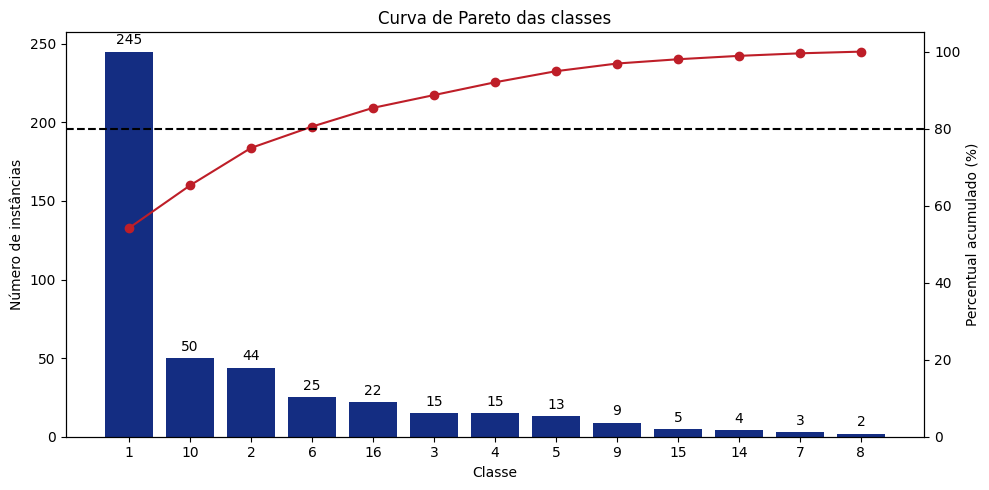

class,1,10,2,6,16,3,4,5,9,15,14,7,8
%,54.2,11.06,9.73,5.53,4.87,3.32,3.32,2.88,1.99,1.11,0.88,0.66,0.44


In [12]:
TARGET = "class"

# Contagem e percentual
contagem = df[TARGET].value_counts().sort_values(ascending=False)
percentual = (contagem / contagem.sum() * 100).round(2)
percentual_acumulado = percentual.cumsum()

## Gráfico de curva de pareto para exibir distribuição da variável target
fig, ax1 = plt.subplots(figsize=(10, 5))

# Barras
barras = ax1.bar(contagem.index.astype(str), contagem.values, color='#142D82')
ax1.set_xlabel("Classe")
ax1.set_ylabel("Número de instâncias")
ax1.set_title("Curva de Pareto das classes")
ax1.bar_label(barras, padding=3)

# Linha do percentual acumulado
ax2 = ax1.twinx()
ax2.plot(
    contagem.index.astype(str),
    percentual_acumulado.values,
    marker="o",
    color='#BE1E28'
)
ax2.set_ylabel("Percentual acumulado (%)")
ax2.set_ylim(0, 105)

# Linha de referência de 80%
ax2.axhline(80, linestyle="--", color='black')

plt.tight_layout()
plt.show()

# Matriz da contribuição percentual de cada classe
matriz_percentual = pd.DataFrame(
    [percentual.values],
    index=["%"],
    columns=contagem.index
)

display(matriz_percentual)

Como observado no gráfico de pareto acima, 54.2% dos registros são referentes à classe de pacientes normais, e os 45.8% restantes são para as classes 2-16, sendo que as classes 1, 10, 2 e 6 representam 80% de todo o conjunto amostral.

### 4.1.2 Avaliação do atributo `j_angle`
A partir da análise exploratória inicial, constatou-se que o atributo `j_angle` (ângulo da onda J) possui cerca de 83.19% dos valores ausentes. Métodos de imputação direta, como substituição por média ou mediana, podem não ser adequados nesse cenário, especialmente se houver associação entre a ausência do atributo e a classe-alvo, caso em que a imputação eliminaria um sinal relevante ao invés de apenas preencher uma lacuna. Para uma tomada de decisão mais informada sobre esse atributo na etapa de modelagem, foi realizado um teste estatístico (Qui-Quadrado) para avaliar a associação entre a ausência do atributo e a classe-alvo.

O teste considerou a variável-alvo de forma binarizada (paciente normal vs. paciente com algum tipo de arritmia), sem distinguir entre os diferentes tipos específicos de arritmia neste primeiro momento. Essa simplificação foi adotada porque a própria associação simples já é suficiente para orientar a decisão sobre o tratamento do atributo na etapa de pré-processamento, independentemente do tipo específico de arritmia envolvido.

In [13]:
# Criado uma cópia do dataframe original para a análise
dfComFlag = df.copy()

# Cria uma flag temporária indicando ausência de j_angle
dfComFlag["j_angle_ausente"] = dfComFlag["j_angle"].isna()

# Cria uma flag temporária para normal (1) vs arritmia (qualquer outro valor)
target_binario = (dfComFlag["class"] == 1).map({True: "normal", False: "arritmia"})

# Tabela de contingência: ausência de j_angle x classe (normal/arritmia)
tabela_contingencia = pd.crosstab(dfComFlag["j_angle_ausente"], target_binario)
print("Tabela de contingência:\n")
display(tabela_contingencia)

# Percentual de ausência dentro de cada grupo (normal vs arritmia)
print("\nPercentual de ausência por grupo:\n")
display(pd.crosstab(dfComFlag["j_angle_ausente"], target_binario, normalize="columns").round(3) * 100)

# Teste qui-quadrado de independência
chi2, p_valor, graus_liberdade, esperado = chi2_contingency(tabela_contingencia)

print(f"\nEstatística qui-quadrado: {chi2:.4f}")
print(f"P-valor: {p_valor:.4f}")

if p_valor < 0.05:
    print("\n→ Há evidência estatística de associação entre a ausência de j_angle e a classe (normal/arritmia).")
else:
    print("\n→ Não há evidência estatística suficiente de associação — a ausência parece ser independente da classe.")

Tabela de contingência:



class,arritmia,normal
j_angle_ausente,,
False,54,22
True,153,223



Percentual de ausência por grupo:



class,arritmia,normal
j_angle_ausente,,
False,26.1,9.0
True,73.9,91.0



Estatística qui-quadrado: 22.2697
P-valor: 0.0000

→ Há evidência estatística de associação entre a ausência de j_angle e a classe (normal/arritmia).


Como pode-se constatar nos resultados acima, o teste qui-quadrado revelou associação estatisticamente significativa (χ² = 22,27; p < 0,0001) entre a ausência desse do valor e a classe-alvo: pacientes normais apresentaram ausência em 91% dos casos, contra 73.9% entre os arrítmicos. Isso sugere que a própria detectabilidade da onda J carrega sinal clínico relevante.

Para complemento da análise, foi feito um teste V de Cramer, para avaliar a força da influência estatística do atributo, segundo a fórmula:

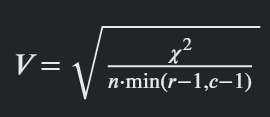

Onde:

> χ²: Estatística do Qui-Quadrado \
> n: Número total de observações da amostra \
> r: Número de linhas \
> c: Número de colunas \
> min(r-1, c-1): O menor valor entre as linhas - 1 e as colunas - 1

In [14]:
# Realizado teste V de Cramer para avaliar o tamanho do efeito da associação estatística

n = tabela_contingencia.to_numpy().sum()
v_cramer = np.sqrt(chi2 / (n * (min(tabela_contingencia.shape) - 1)))

print(f"V de Cramér: {v_cramer:.3f}")

V de Cramér: 0.222


O resultado de 0.22 indica uma influência moderada do campo na variável target, e por esse motivo, na etapa de pré-modelagem, optou-se por remover o valor numérico original e substituí-lo por uma variável binária indicando sua presença ou ausência, preservando a informação relevante identificada pelo teste.

### 4.1.3 Análises de correlação e distribuição de variáveis
Em sequência, foi realizada uma análise básica correlação dos atributos com a variável target, considerando a mesma distribuição binária usada anteriormente (pacientes normais e arritmicos), e levantada a correlação dos 20 principais atributos.

Pode-se notar que não existe um atributo singular altamente correlacionado as classes, sugerindo a necessidade de utilização de algoritmos de redução de dimensionalidade, como análise de componentes principais (PCA) em vez de seleção manual de atributos.

In [15]:
correlacoes = dfComFlag.corr(numeric_only=True)["class"].drop("class").sort_values(key=abs, ascending=False)

print("Top 20 features mais correlacionadas com o target:")
display(correlacoes.head(20).to_frame("correlação"))

Top 20 features mais correlacionadas com o target:


,correlação
V1_rprime_width,0.368876
qrs_duration,0.323879
V1_intrinsic_deflections,0.313982
V2_rprime_width,0.282523
V1_rprime_amp,0.235488
V2_rprime_amp,0.218811
DI_s_amp,-0.197555
DI_s_width,0.195198
V3_s_amp,-0.189458
DII_s_width,0.183083


Complementarmente, também avaliou-se a colinearidade entre os atributos. Como a maioria dos atributos do dataset são derivados de 12 canais do ECG, é esperado que existam atributos altamente correlacionados entre si, o que de fato foi encontrado.
A tabela abaixo representa os 20 primeiros campos com o maior grau de correlação, com corte acima de 80%, porém existem 76 colunas no dataset com alta correlação.

Entende-se a partir dessa análise que o conjunto de dados se beneficia da utilização de PCA para redução da dimensionalidade para modelos que sejam sensíveis à maldição da dimensionalidade e a colinearidade de variáveis.

Modelos baseados em ensembles e árvores, por outro lado, podem ainda performar de maneira adequada, porém com um maior custo de processamento e interpretabilidade do modelo, via diluição da importância entre atributos altamente correlacionados entre si.

In [16]:
# Separação das features com a variável target
X = df.drop(columns=["class"])
y = df["class"]

In [17]:
corr_matrix = X.corr(numeric_only=True).abs()

# pega só o triângulo superior pra não contar pares duplicados (A-B e B-A)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# pares com correlação acima de 0.8
pares_altos = upper.stack().sort_values(ascending=False)
pares_altos = pares_altos[pares_altos > 0.8]

print(f"Número de pares de features com correlação > 0.8: {len(pares_altos)}")
display(pares_altos.head(20).to_frame("correlação"))

Número de pares de features com correlação > 0.8: 76


,,correlação
AVR_sprime_width,AVR_sprime_amp,1.000000
V4_sprime_width,V4_sprime_amp,0.999287
V6_rprime_width,V6_rprime_amp,0.997769
AVF_sprime_width,AVF_sprime_amp,0.967353
V3_sprime_width,V3_rprime_amp,0.966664
V1_sprime_width,V1_sprime_amp,0.957753
V2_sprime_width,V2_sprime_amp,0.953208
AVL_rprime_width,AVL_rprime_amp,0.941517
DIII_sprime_width,DIII_sprime_amp,0.940529
DI_q_width,DI_q_amp,0.936717


Foi feita uma avaliação da distribuição de exemplos por sexo, e constatou-se maior predominância de mulheres no conjunto de dados (55.09%) do que homens (44.91%). Mesmo sendo minoria, os homens são maioria nos casos de arritmia positiva (58.12%) comparado a mulheres (35.74%).



In [18]:
contagem = df["sex"].value_counts().rename(index={0: "Masculino", 1: "Feminino"}).sort_index()
percentual = (contagem / len(df) * 100).round(2)

pd.DataFrame({
    "contagem": contagem,
    "percentual (%)": percentual
})

,contagem,percentual (%)
sex,,
Feminino,249,55.09
Masculino,203,44.91


In [19]:
pd.crosstab(df["sex"], target_binario, normalize="index").rename(index={0: "Masculino", 1: "Feminino"}).sort_index() * 100

class,arritmia,normal
sex,,
Feminino,35.742972,64.257028
Masculino,58.128079,41.871921


Finalmente, foi feita uma avaliação da distribuição dos atributos fisiológicos dos pacientes.

A distribuição do eixo X para a variáveis `height` (altura) chamou atenção, pois ela se estende até o valor 800, indicando a presença de outliers fisiologicamente implausíveis, os quais foram explorados em sequência.

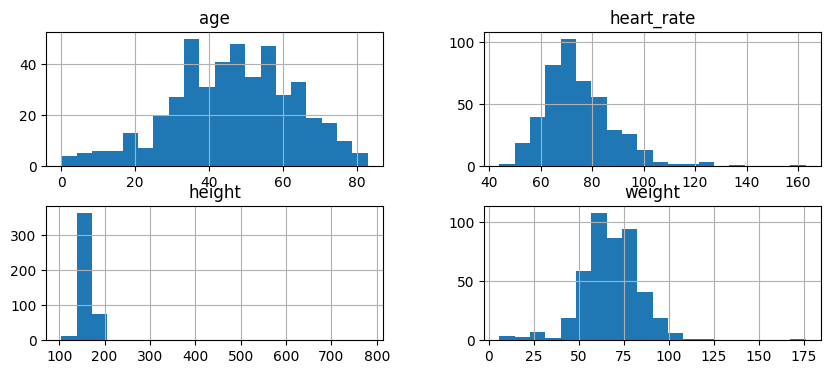

In [20]:
df[["age", "heart_rate", "height", "weight"]].hist(figsize=(10, 4), bins=20)
plt.show()

A discrepância nos valores do eixo `X` para a variável `height` indica a existência de outliers.

Para validar a existência de outliers, foi feita uma análise descritiva dos atributos idade, altura, peso e ritmo cardíaco, exibido abaixo.

In [21]:
df[["age", "height", "weight", "heart_rate"]].describe()

,age,height,weight,heart_rate
count,452.000000,452.000000,452.000000,451.000000
mean,46.471239,166.188053,68.170354,74.463415
std,16.466631,37.170340,16.590803,13.870684
min,0.000000,105.000000,6.000000,44.000000
25%,36.000000,160.000000,59.000000,65.000000
50%,47.000000,164.000000,68.000000,72.000000
75%,58.000000,170.000000,79.000000,81.000000
max,83.000000,780.000000,176.000000,163.000000


A análise permitiu identificar a existência de valores discrepantes para a altura, onde há um valor máximo de 780 cm.

A partir desse achado, buscou-se identificar as linhas com outliers para altura acima de 2 metros (já que 75% das ocorrências são abaixo de 175 cm), e pessoas com peso abaixo de 40 kg e acima de 15 anos.

Identificaram-se três registros com valores fisiologicamente implausíveis: altura de 780cm e 608cm (linhas 141 e 316), e peso de 18kg incompatível com idade adulta e altura de 186cm (linha 126), descritos abaixo.

In [22]:
print("\nAltura > 200:")
display(df[df["height"] > 250][["age", "height", "weight", "heart_rate", "class"]])

print("\nPeso < 40 e idade > 15:")
display(
    df[(df["weight"] < 40) & (df["age"] > 15)]
    [["age", "height", "weight", "heart_rate", "class"]]
)


Altura > 200:


,age,height,weight,heart_rate,class
141,1,780,6,138.0,5
316,0,608,10,163.0,5



Peso < 40 e idade > 15:


,age,height,weight,heart_rate,class
126,58,186,18,70.0,1


Também foi realizada uma contagem de pacientes abaixo de 18 anos, visto que o gráfico de distribuição de pacientes por idade indica poucas amostras.

A existência de apenas 24 amostras (5.31% do dataset) indicam que o modelo pode não ser apropriado ao uso para pacientes pediátricos, visto que as características de ECG são diferentes de pacientes adultos.

In [23]:
pediatricos = (df["age"] < 18).sum()
total = len(df)
percentual = (pediatricos / total * 100).round(2)

print(f"Pacientes < 18 anos: {pediatricos} ({percentual}% do total)")

Pacientes < 18 anos: 24 (5.31% do total)


## 4.2 Síntese da análise exploratória

A EDA revelou um desbalanceamento severo da variável target: 4 classes concentram 80% do dataset, com a classe "normal" representando 54,2% do total, enquanto classes 11, 12 e 13 não possuem nenhuma instância e as classes 7 e 8 contam com apenas 2 e 3 registros, respectivamente.

Diante do desbalanceamento severo e da raridade das classes positivas de arritmia, optou-se por reagrupar o problema em uma classificação binária (normal vs. arrítmico), já que a dispersão original entre múltiplas classes minoritárias tenderia a fazer os modelos favorecerem a classe majoritária na ausência de tratamento específico.

Foi feita uma avaliação da relação de sexo com a variável alvo, e percebeu-se um desbalanceio interno na distribuição de sexo para as amostras, onde a maioria são do sexo feminino (55.09%), mas são minoria para casos de arritmia (35.74%), enquanto os homens representam 44.91% das amostras, mas são maioria dos casos de arritmia (58.12%), o que pode ter implicações práticas ao modelo final, que corre o risco de subestimar arritmia para mulheres, e sobreestimar para homens, apenas pela variável sexo.

Quanto a valores ausentes, destaca-se o atributo `j_angle`, com 83.19% de ausência. Um teste qui-quadrado identificou associação estatisticamente significativa entre essa ausência e a classe-alvo (χ² = 22,27; p < 0,0001), com uma força estatística moderada pelo teste V de Cramer (0.22), onde pacientes normais apresentaram ausência em 91% dos casos, contra 73,9% entre os arrítmicos. Isso indica que a própria detectabilidade da onda J carrega sinal clínico relevante, motivando a substituição do valor numérico original por uma flag binária de presença/ausência, em vez da simples remoção da coluna. Outros atributos (`p_angle`, `t_angle`, `qrst_angle`, `heart_rate`) apresentaram ausência baixa, tratada via imputação por mediana.

Identificaram-se também outliers fisiologicamente implausíveis (altura de 780cm e 608cm, peso de 18kg incompatível com idade e altura registradas), tratados pontualmente como valores ausentes. Como os outliers foram detectados em registros isolados, e em poucas dimensões (altura e peso), foi decidido a substituição do outlier por valores ausentes.

Em relação à escala, atributos como `age`, `height` e `weight` apresentam ordens de grandeza distintas entre si e dos atributos de amplitude (`*_amp`), reforçando a necessidade de padronização (`StandardScaler`) para modelos sensíveis à escala. Sobre as categorias raras nos atributos, diversas colunas condicionais relacionadas a ondas R'/S' e flags morfológicas (ragged/diphasic) apresentaram variância zero em todos os 452 registros, sendo removidas por não conterem informação discriminativa.

A alta dimensionalidade (279 atributos) frente ao número reduzido de amostras (452), somada à colinearidade esperada entre os múltiplos canais do ECG, confirmada pela identificação de 76 colunas com correlação superior a 80%, sugere que modelos sensíveis à maldição da dimensionalidade (como KNN) tendem a performar mal, enquanto modelos com boa capacidade de regularização ou robustez à colinearidade (SVM, Regressão Logística regularizada, Random Forest) são mais promissores. Essa colinearidade reforça a utilidade do PCA para modelos baseados em distância ou gradiente, mas não para modelos baseados em árvore, que lidam nativamente com atributos correlacionados.

Assim, definiu-se o uso de pipelines distintos: um com `PCA` e `StandardScaling` para modelos lineares e baseados em distância, e outro sem esse tratamento para modelos de árvore e ensembles, como Random Forest.

# 5. Preparação dos dados e divisão treino/teste


Primeiramente, foram realizados os seguintes ajustes no dataset a partir dos achados da análise exploratória:

*   Criação da flag `j_angle_ausente` e exclusão do campo `j_angle` original;
*   Tratar outliers pontuais como valores ausentes;
*   Realizar um agrupamento do target onde a classe 1 (pacientes normais) foi convertida a 0, e demais classes (arritmia) foi agrupada como 1.

Esse tratamento do target foi feito devido ao distribuição altamente desbalanceada das classes positivas e baixa quantidade de registros para certas classes. A fim de que o modelo ainda seja útil em triagens clínicas, a classificação binária entre paciente normal e com arritmia foi considerada adequada, e pode ser benéfica à métrica alvo do modelo (recall).

In [24]:
# Criado uma coluna de flag ausente para j_angle, do tipo inteiro
df["j_angle_ausente"] = df["j_angle"].isna().astype(int)

# Realizado um agrupamento de classes onde 1 (paciente normal) é substituido por 0, e as demais (arritmia) por 1.
df['class'] = np.where(df['class'] == 1, 0, 1)

# tratamento de outliers detectados na descoberta de dados, onde os valores fisiologicamtne implausíveis foram substituídos por nulos
df.loc[126, "weight"] = np.nan   # 18kg incompatível com 58 anos / 186cm
df.loc[141, "height"] = np.nan  # 780cm impossível para qualquer idade
df.loc[316, "height"] = np.nan  # 608cm impossível para qualquer idade

In [25]:
# Configuração do problema
TARGET = "class"
PROBLEM_TYPE = "classificacao"

# Realizado a eliminação de colunas com variância igual a 0, e j_angle.
DROP_COLUMNS = ['DI_sprime_width', 'AVL_sprime_width',
                'AVL_ragged_r', 'V4_diphasic_p', 'V5_sprime_width',
                'V4_ragged_p', 'AVL_sprime_amp', 'AVF_ragged_p',
                'V5_sprime_amp', 'DI_sprime_amp', 'V6_diphasic_p',
                'V6_ragged_t', 'V5_ragged_t', 'V6_sprime_width',
                'V5_ragged_p', 'V5_ragged_r', 'V6_sprime_amp', 'j_angle']

columns_to_exclude = set(DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: class
Número de features: 262
Features: ['age', 'sex', 'height', 'weight', 'qrs_duration', 'pr_interval', 'qt_interval', 't_interval', 'p_interval', 'qrs_angle', 't_angle', 'p_angle', 'qrst_angle', 'heart_rate', 'DI_q_width', 'DI_r_width', 'DI_s_width', 'DI_rprime_width', 'DI_intrinsic_deflections', 'DI_ragged_r', 'DI_diphasic_r', 'DI_ragged_p', 'DI_diphasic_p', 'DI_ragged_t', 'DI_diphasic_t', 'DII_q_width', 'DII_r_width', 'DII_s_width', 'DII_rprime_width', 'DII_sprime_width', 'DII_intrinsic_deflections', 'DII_ragged_r', 'DII_diphasic_r', 'DII_ragged_p', 'DII_diphasic_p', 'DII_ragged_t', 'DII_diphasic_t', 'DIII_q_width', 'DIII_r_width', 'DIII_s_width', 'DIII_rprime_width', 'DIII_sprime_width', 'DIII_intrinsic_deflections', 'DIII_ragged_r', 'DIII_diphasic_r', 'DIII_ragged_p', 'DIII_diphasic_p', 'DIII_ragged_t', 'DIII_diphasic_t', 'AVR_q_width', 'AVR_r_width', 'AVR_s_width', 'AVR_rprime_width', 'AVR_sprime_width', 'AVR_intrinsic_deflections', 'AVR_

In [26]:
# Divisão dos dados
X = df[features].copy()
y = df[TARGET].copy()

stratify_arg = y
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=stratify_arg
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (339, 262) | Teste: (113, 262)


## 5.1 Justificativa da divisão

Como o dataset é pequeno, foi escolhida uma divisão 75/25 entre treino e teste, de forma a garantir registros suficientes e relevantes no conjunto de teste para avaliar a capacidade de generalização do modelo. Entendeu-se que uma partição de teste menor (como 20%) poderia comprometer essa avaliação, dado o número reduzido de exemplos disponíveis para validar a generalização, enquanto partições maiores (como 30/70) reduziriam excessivamente a quantidade de exemplos disponíveis para treinamento.

A etapa descrita, denominada holdout, é necessária para que o modelo não seja treinado com a totalidade dos registros da base, permitindo avaliar sua capacidade de generalização em dados não vistos e, por consequência, estimar sua performance em um ambiente produtivo. Já a validação cruzada é aplicada dentro do conjunto de treino para obter uma estimativa de desempenho mais robusta do que a fornecida por um único split interno, já que este poderia ser sensível à composição específica dos registros nele presentes.

A estratificação (`stratify=y`) foi mantida mesmo após o agrupamento do target, pois ainda existe desbalanceamento relevante entre as classes (ainda que reduzido em relação às 16 classes originais). A estratificação garante que a proporção entre classes seja preservada tanto no treino quanto no teste, evitando que uma divisão puramente aleatória concentre desproporcionalmente alguma classe em um dos lados.

O vazamento de dados é evitado por meio do uso de pipelines, que garantem que transformações dependentes da distribuição dos dados, como imputação por mediana, padronização e PCA sejam ajustadas somente nos dados de treino em cada fold da validação cruzada, e aplicadas de forma consistente ao conjunto de teste apenas na avaliação final.

# 6. Pré-processamento e pipeline


In [27]:
# Identificação automática simples de colunas numéricas e categóricas.

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

print("Colunas numéricas:", len(num_cols))
print("Colunas categóricas:", len(cat_cols))

# Preprocessador para modelos baseados em árvore
preprocess_tree = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), num_cols)
], remainder="drop")

# Preprocessador para modelos sensíveis à escala/dimensionalidade
preprocess_scaled = ColumnTransformer(transformers=[
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95))
    ]), num_cols)
], remainder="drop")

Colunas numéricas: 262
Colunas categóricas: 0


## 6.1 Decisões de pré-processamento

Foi realizada a construção de dois pipelines independentes de pré-processamento, cada um adequado ao tipo de modelo que alimenta.
O primeiro, denominado `preprocess_tree` foi construido para o treinamento de modelos baseados em árvores de decisão, como Decision Tree e Random Forest. Esse pipeline realiza apenas a imputação de valores ausentes por meio de mediana.

Diferentemente do segundo pipeline, `preprocess_tree` não aplica padronização nem redução de dimensionalidade, pois modelos de árvore são invariantes à escala dos atributos, visto que a decisão de cada nó depende apenas dos pontos de corte ordinais, e a ausência de PCA preserva a interpretabilidade individual de cada atributo da estrutura das árvores.

Já a escolha da mediana como substituição de valores ausentes se justifica pela resistência do indicador a outliers e porque os atributos na qual esse método foi aplicado possuem valores ausentes considerados baixos o suficiente para que o mecanismo de ausência tenha impacto marginal na imputação.

O segundo pipeline implementado, `preprocess_scaled`, foi construído para o treinamento de modelos sensíveis à escala e dimensionalidade, como regressão logística e SVM. O pipeline conta com a imputação de valores ausentes pelo mesmo método do `preprocess_tree`, e a padronização por meio do escore z do `standardScaler` foi aplicada pois esses algoritmos são sensíveis à magnitude das variáveis, e atributos com escalas maiores predominariam sobre as de escala menor e prejudicaria o aprendizado do modelo. O PCA foi aplicado em seguida para reduzir a dimensionalidade do dataset, mitigando o risco da "maldição da dimensionalidade" e overfitting do dataset. Nota-se que existe uma perda de interpretabilidade do modelo por conta do uso do PCA, mas foi uma concessão necessária dado que não foi identificada relação linear expressiva entre atributos individuais e a variável alvo na EDA.

No processamento do pipeline, não foi necessária a criação de novas variáveis. Nota-se, porém, que anteriormente ao pré processamento, foi feita a substituição da coluna `j_angle` por uma flag que indica a presença ou ausência da onda, como descrito na seção `5.1`. Em um cenário de produção, essa conversão precisaria ser implementada no software embarcado ao sistema de ECG ou na camada de ingestão antes que o registro chegue ao pipeline de inferência, garantindo que o atributo esteja disponível no mesmo formato usado durante o treinamento.



# 7. Baseline e modelos candidatos


In [28]:
# Modelo Baseline
baseline = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", DecisionTreeClassifier(random_state=SEED))
])

# Modelos candidatos
candidates = {
    "SVM": Pipeline(steps=[
        ("preprocess", preprocess_scaled),
        ("model", SVC(probability=True, random_state=SEED))
    ]),
    "LogisticRegression": Pipeline(steps=[
        ("preprocess", preprocess_scaled),
        ("model", LogisticRegression(max_iter=500, random_state=SEED))
    ]),
    "RandomForest": Pipeline(steps=[
        ("preprocess", preprocess_tree),
        ("model", RandomForestClassifier(random_state=SEED))
    ])
}

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['SVM', 'LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos

O modelo baseline escolhido foi o `"Decision Tree"`, por conta de sua fácil interpretabilidade, capacidade de modelar relações não lineares entre os atributos e a classe alvo, estabelecendo uma referência compreensível para a comparação com modelos mais complexos. Ainda, o algoritmo demanda um pré processamento simples, como o utilizado no pipeline `preprocess_tree`, onde foi realizada apenas a imputação de valores ausentes.
O algoritmo também é menos sensível à alta dimensionalidade do modelo do que métodos baseados em distância, como SVM, o que permite a sua aplicação sem o uso de técnicas de redução de dimensionalidade como o PCA. Visto que a interpretabilidade do modelo foi considerada uma característica desejável para contextos clínicos em que seria aplicado, o `Decision Tree` foi então considerado o melhor modelo de referência.
Nota-se porém, que o reduzido número de observações em relação à quantidade de atributos pode levar o algoritmo a apresentar elevada propensão ao overfitting quando não houver restrições em sua profundidade. Neste trabalho, optou-se por não limitar a complexidade da árvore no modelo baseline, uma vez que, além da métrica principal de desempenho (recall), também foi avaliada posteriormente a capacidade de generalização dos modelos por meio da diferença entre o desempenho em treinamento e validação.

Para os modelos candidatos, foram escolhidos o `Support Vector Machine (SVM)`, `Logistic Regression` e `Random Forest` por diferentes razões. O `SVM` foi selecionado devido a sua capacidade de modelar fronteiras de decisão complexas e não lineares, e possui maior capacidade de generalização que uma árvore isolada. Um contraponto a esse atributo seria a perda de interpretabilidade do modelo devido ao uso de PCA para redução da dimensionalidade.

Já o algoritmo `Logistic Regression` foi selecionado por ser um modelo linear de baixo custo computacional e capacidade de aprendizado de relações lineares. Uma performance de recall aderente ao objetivo do trabalho, ou similar ao SVM caso ambos tenham performance satisfatória o tornaria um modelo candidato à seleção final. Embora seja naturalmente interpretável quando aplicada diretamente aos atributos originais, neste trabalho sua utilização exigiu a aplicação de PCA, fazendo com que seus coeficientes passassem a representar componentes principais em vez das variáveis originais, reduzindo a interpretabilidade do modelo. Ainda assim, sua simplicidade e eficiência a tornam uma alternativa relevante para comparação, especialmente caso apresente desempenho semelhante ao do SVM.

Vale ressaltar que ambos os modelos mencionados acima utilizam o pipeline `preprocess_scaled`, que além da aplicação do uso de análise de componentes principais, também emprega o uso de tratamento de escala por meio do Standard Scaler, um requisito para os modelos devido a diferença de escalas entre as variáveis.

Finalmente, o algoritmo `Random Forest` foi considerado um bom candidato por combinar múltiplas árvores de decisão, reduzindo a variância do modelo e tornando-o mais robusto ao overfitting do que uma árvore individual, desde que seus hiperparâmetros sejam adequados ao dataset. Assim como a Decision Tree, não requer padronização dos atributos nem redução de dimensionalidade para seu treinamento. Embora não permita a interpretação direta das regras de decisão, fornece medidas de importância das variáveis, oferecendo um nível intermediário de interpretabilidade. Dessa forma, o Random Forest representa um modelo capaz de conciliar elevado desempenho preditivo, baixa necessidade de pré-processamento e uma interpretação parcial da contribuição de cada atributo para a classificação.

# 8. Treinamento e avaliação inicial


Como o dataset possui um tamanho relativamente pequeno, optou-se por realizar a avaliação inicial dos modelos por meio de validação cruzada com 5 folds, em vez de uma avaliação com um único split (holdout), a fim de obter uma estimativa mais estável e confiável do desempenho dos modelos.

In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

results = {}
trained_models = {}
scoring = {
    "recall": "recall",
    "pr_auc": "average_precision"
}

for name, model in {"baseline": baseline, **candidates}.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    scores = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True
    )

# Criado um dataframe para exibir o tempo de treinamento, e pontuações dos modelos para o conjunto de treino e conjunto de validação.
    results[name] = {
        "train_time_s": round(train_time, 3),
        "cv_train_recall": scores["train_recall"].mean(),
        "cv_val_recall": scores["test_recall"].mean(),
        "cv_train_pr_auc": scores["train_pr_auc"].mean(),
        "cv_val_pr_auc": scores["test_pr_auc"].mean(),
    }
    trained_models[name] = model

show_results_table(results)

,train_time_s,cv_train_recall,cv_val_recall,cv_train_pr_auc,cv_val_pr_auc
baseline,0.058,1.000000,0.722581,1.000000,0.659204
SVM,0.179,0.787097,0.645161,0.951037,0.836009
LogisticRegression,0.255,0.850000,0.690323,0.952448,0.779250
RandomForest,0.813,1.000000,0.703226,1.000000,0.845576


## 8.1 Análise dos resultados iniciais

Analisando os resultados iniciais com base nas métricas escolhidas, recall e área sob a curva de precisão-recall (PR-AUC), observou-se que o baseline teve recall de 0.722581, levemente abaixo da métrica alvo de 0.70, e PR-AUC de 0.659204.

Dentre os modelos candidatos, todos superaram o baseline em PR-AUC, indicando maior capacidade de identificar corretamente amostras da classe positiva sem inflar falsos positivos, o que é desejável em contextos de triagem clínica. Porém, apenas o Random Forest superou a métrica alvo de recall (0.703226), acompanhado do melhor PR-AUC do grupo (0.845576).

O tempo de treinamento foi considerado aceitável para todos os modelos, visto que todos tiveram um tempo de treinamento inferior a 1 segundo.

Para verificar a hipótese de overfitting levantada no item `4`, foi feita uma comparação do recall e PR-AUC entre os conjuntos de treino e validação. Os modelos Baseline e Random Forest memorizaram o conjunto de treino, pontuando recall de 1.0 e PR-AUC de 1.0, com queda substancial na validação, confirmando overfitting nos dois. Isso já era esperado nos modelos baseados em árvore, já que não houve ajuste de hiperparâmetros de profundidade ou número mínimo de amostras por folha, deixando as árvores livres para crescer sem restrição. SVM e Logistic Regression apresentaram overfitting mais moderado, mas ainda relevante: gap de 0.1419 no recall treino-validação para o SVM e 0.1597 para o Logistic Regression.

A detecção de overfitting não foi surpreendente dentre os modelos candidatos, já que na etapa de EDA foi hipotetizado que a alta dimensionalidade do modelo e baixa quantidade de amostras podem gerar esse resultado. É possível supor, ainda que não validado, que mesmo com a aplicação do PCA para o SVM e Logistic regression, parametrizado a preservar 95% da variância do modelo, ainda tenha havido geração de um número elevado de componentes principais, o que manteria a dimensionalidade efetiva alta.

Mesmo com overfitting, o recall de validação do Random Forest (0.7032) ainda supera a meta, e seu PR-AUC de validação (0.8456) permanece o melhor entre os modelos, inclusive o Baseline. Ele também tem a vantagem de manter os atributos em sua forma original, sem a transformação de PCA aplicada a SVM e Logistic Regression, o que preserva interpretabilidade, fazendo desse o modelo escolhido para a otimização dos hiperparâmetros, a fim de ter-se um modelo interpretável, com recall acima do target, e desejavelmente com uma boa capacidade de generalização.



# 9. Validação e otimização de hiperparâmetros

Conforme discutido no item `8.1`, o modelo escolhido para a otimização foi o Random Forest. Essa etapa teve o objetivo de maximizar tanto o recall quanto reduzir o overfitting do modelo. Para esse fim, foram definidos os seguintes hiperparâmetros a serem otimizados:
*  `n_estimators`: Quantidade de árvores usadas no modelo. Um número maior de árvores geralmente leva a uma melhor generalização por meio de médias dos resultados das árvores.
*  `max_depth`: Quantidade máxima da profundidade de uma árvore. Esse hiperparâmetro não possui limite no modelo padrão, e pode levar ao overfitting do modelo por meio da memorização do conjunto de teste e geração de limiares de decisão extremamente complexos.
*  `min_samples_leaf`: Quantidade mínima de amostra em uma folha. É interessante explorar valores que permitam uma quantidade adequada de amostras para ter-se uma boa generalização e evitar overfitting.
*  `min_samples_split`: Quantidade mínima de amostras em uma folha para permitir a separação em nós. Esse hiperparâmetro permite limitar a quantidade de separações de amostras, tornando a árvore mais simples e generalista.
*  `max_features`: Define a função usada para o cálculo da quantidade de atributos a serem considerados ao fazer a divisão de um nó. Uma quantidade menor de atributos considerados pode ajudar a reduzir overfitting, porém uma quantidade muito pequena pode levar a underfitting. Para a busca de hiperparâmetros, considerou-se no espaço amostral todas as opções disponíveis na biblioteca do sklearn, que são `sqrt`, `log2` e `None`.

O hiperparâmetro `random_state` foi utilizado para a definição da seed no modelo e repetibilidade dos resultados, a seed usada foi a mesma definida para os outros blocos de código.

A busca dos hiperparâmetros foi realizada por meio de um estudo do Optuna. O Optuna é uma biblioteca de otimização automatizada de hiperparâmetros de modelos, onde é possível definir sugestões de valores de hiperparâmetros e a ferramenta realiza estudos automatizados para escolha da combinação ideal que melhor maximize uma métrica alvo.

Como foi observado anteriormente que os modelos em árvore tendem a ter overfitting nesse dataset para a métrica de recall, essa foi definida como a métrica a ser maximizada, porém com uma função de penalidade, onde é feito para cada estudo uma validação cruzada de 5 splits entre o conjunto de treino e teste, calculado o gap de recall entre ambos, e subtraído do recall de treino o valor do gap multiplicado por 0.5 (valor definido de forma arbitrária). Esse valor de "recall ajustado" é usado como o resultado do estudo. A função penalidade foi definida pois a métrica de recall pura faria com que o Optuna o otimizasse agressivamente e poderia sugerir hiperparâmetros que resultem em um modelo com overfitting alto.

A melhor configuração foi `n_estimators`=190, `max_depth`=8, `min_samples_leaf`=5, `min_samples_split`=20, `max_features`=None, resultando em um recall ajustado de 0.70564.

In [30]:
rf_param_space = {
    'n_estimators': lambda t: t.suggest_int('n_estimators', 50, 300),
    'max_depth': lambda t: t.suggest_int('max_depth', 2, 8),
    'min_samples_leaf': lambda t: t.suggest_int('min_samples_leaf', 2, 20),
    'min_samples_split': lambda t: t.suggest_int('min_samples_split', 2, 20),
    'max_features': lambda t: t.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    'random_state': lambda t: t.suggest_int('random_state', SEED, SEED)
}

objective_rf = make_objective(
    model_class=RandomForestClassifier,
    param_space=rf_param_space,
    preprocess=preprocess_tree,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring='recall',
    gap_penalty=0.5
)

study = optuna.create_study(direction='maximize', sampler=Sampler)
study.optimize(objective_rf, n_trials=30)

print("Best Parameters:", study.best_params)
print("Best Score (ajustado):", study.best_value)

[I 2026-07-05 03:18:09,758] A new study created in memory with name: no-name-6799b37c-a6cf-476f-8695-45fafe3b30c8
[I 2026-07-05 03:18:17,199] Trial 0 finished with value: 0.49838709677419346 and parameters: {'n_estimators': 214, 'max_depth': 2, 'min_samples_leaf': 20, 'min_samples_split': 11, 'max_features': 'sqrt', 'random_state': 1000}. Best is trial 0 with value: 0.49838709677419346.
[I 2026-07-05 03:18:21,438] Trial 1 finished with value: 0.5233870967741934 and parameters: {'n_estimators': 149, 'max_depth': 3, 'min_samples_leaf': 17, 'min_samples_split': 5, 'max_features': 'sqrt', 'random_state': 1000}. Best is trial 1 with value: 0.5233870967741934.
[I 2026-07-05 03:18:28,958] Trial 2 finished with value: 0.5169354838709677 and parameters: {'n_estimators': 236, 'max_depth': 2, 'min_samples_leaf': 18, 'min_samples_split': 20, 'max_features': 'sqrt', 'random_state': 1000}. Best is trial 1 with value: 0.5233870967741934.
[I 2026-07-05 03:18:33,498] Trial 3 finished with value: 0.5508

Best Parameters: {'n_estimators': 190, 'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 20, 'max_features': None, 'random_state': 1000}
Best Score (ajustado): 0.7056451612903225


Como o Optuna utiliza como métrica alvo a maximização do recall ajustado, uma métrica que é calculada pela fórmula:

`Recall Ajustado` = `Recall` - `Gap absoluto entre recall de treino e teste` * `0.5`

Foi feito um novo treinamento do modelo e avaliação de sua performance de recall entre o conjunto de treino e teste, para comparar com o modelo original do item `8`.

In [31]:
# Melhores hiperparâmetros encontrados pelo Optuna
best_params = study.best_params

# Definição da validação cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# Pipeline do modelo otimizado
RF_Otimizado = Pipeline(steps=[
    ("preprocess", preprocess_tree),
    ("model", RandomForestClassifier(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        min_samples_leaf=best_params["min_samples_leaf"],
        min_samples_split=best_params["min_samples_split"],
        max_features=best_params["max_features"],
        random_state=SEED
    ))
])

# Coleta do tempo de treinamento
t0 = time.time()
RF_Otimizado.fit(X_train, y_train)
train_time = time.time() - t0

# Coleta de pontuações, com realização de validação cruzada de 5 folds
scoring = {
    "recall": "recall",
    "pr_auc": "average_precision"
}

scores = cross_validate(
    RF_Otimizado, X_train, y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True
)

resultados_cv = {
    "RF_Otimizado": {
        "train_recall": scores["train_recall"].mean(),
        "val_recall": scores["test_recall"].mean(),
        "train_pr_auc": scores["train_pr_auc"].mean(),
        "val_pr_auc": scores["test_pr_auc"].mean(),
        "train_time_s": round(train_time,3)
    }
}

pd.DataFrame(resultados_cv).T

,train_recall,val_recall,train_pr_auc,val_pr_auc,train_time_s
RF_Otimizado,0.930645,0.780645,0.985351,0.878693,4.073


## 9.1 Discussão da otimização

Após a busca de otimização de hiperparâmetros, fez-se um novo treinamento do modelo, e avaliou-se sua pontuação para recall e PR-AUC para os conjuntos de treino e teste, com uma validação cruzada de 5 folds, e pode-se constatar uma melhora sobre o recall no conjunto de teste. No modelo inicial, o recall foi de 0.70, muito próximo do limite mínimo de aceitação, enquanto o modelo otimizado teve um recall de 0.78, ainda, o modelo otimizado teve um PR-AUC de 0.88, superior a pontuação de 0.84 do modelo inicial.

Os hiperparâmetros escolhidos pelo Optuna fazem sentido diante do objetivo de reduzir-se o overfitting e ainda ter um recall satisfatório (>0.70). O `max_depth` de 8 é consideravelmente menor que o padrão ilimitado do sklearn, restringindo a complexidade das árvores e limitando a capacidade do modelo de memorizar padrões específicos do conjunto de treino. Da mesma forma, os valores de `min_samples_leaf` (5) e `min_samples_split` (20) são bem superiores aos padrões da biblioteca (1 e 2, respectivamente), exigindo uma quantidade maior de amostras para formar uma folha ou realizar uma divisão, o que resulta em árvores mais simples e generalistas. O `n_estimators` de 190 favorece maior estabilidade nas previsões por meio da média de um número razoável de árvores, sem custo computacional excessivo.

O único hiperparâmetro escolhido que poderia sugerir uma propensão ao overfitting foi o `max_features` ser definido como "None", que considera todos os atributos em cada divisão. No entanto, seu efeito parece ter sido compensado pelas restrições impostas pelos demais hiperparâmetros, e os logs de estudos do Optuna sugerem que outras configurações para esse hiperparâmetro não conseguiram atingir um recall ajustado superior ao dessa configuração.

Ao avaliar o overfitting do modelo, pode-se constatar uma redução quando comparado ao treino inicial do item `8`. No modelo inicial, o gap entre o recall sobre o conjunto de teste e treino foi de 0.296774, além de ter um escore de 1 para o conjunto de treino, indicando que o modelo memorizou o dataset. Após a otimização dos hiperparâmetros, o gap entre o treino e teste caiu para 0.15, e o recall do conjunto de treino foi de 0.930645. Isso indica que o modelo ainda apresenta sinais de overfitting, porém a função penalidade aplicada na etapa de otimização foi eficaz tanto em melhorar a performance geral do modelo quanto em reduzir o overfitting.

Devido a limitações de tempo, parametrizou-se uma busca de 30 estudos. Foi testada anteriormente a realização de uma quantidade maior, como 100 estudos, porém observou-se que os ganhos em recall ajustado tinham retorno decrescente, o que poderia não representar um impacto significativo ao modelo final considerando o tempo de otimização. Caso não houvesse restrições de tempo, seriam avaliados outros espaços de busca de hiperparâmetros ao estudo automatizado, e outras formas de maximizar o valor de recall além da função penalidade escolhida, como otimizar o modelo para maximizar o score f1, ou o PR-AUC para indiretamente ter-se um recall acima da métrica alvo, o que não foi avaliado.


# 10. Avaliação final no conjunto de teste


Modelo final: RandomForest_otimizado
              precision    recall  f1-score   support

      Normal       0.80      0.87      0.83        61
    Arritmia       0.83      0.75      0.79        52

    accuracy                           0.81       113
   macro avg       0.82      0.81      0.81       113
weighted avg       0.82      0.81      0.81       113



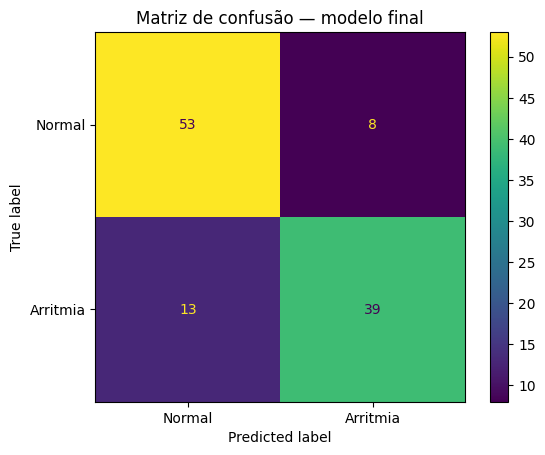

In [32]:
final_model = RF_Otimizado
final_model.fit(X_train, y_train)
final_model_name = "RandomForest_otimizado"

trained_models[final_model_name] = final_model

print("Modelo final:", final_model_name)

y_pred = final_model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=["Normal", "Arritmia"]))
ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test, display_labels=["Normal","Arritmia"])
plt.title("Matriz de confusão — modelo final")
plt.show()

Adicionalmente, foi feito um teste do PR-AUC, métrica auxiliar ao recall

In [33]:
proba_final = final_model.predict_proba(X_test)[:, 1]

pr_auc_final = average_precision_score(y_test, proba_final)

print(f"PR-AUC: {pr_auc_final:.4f}")

PR-AUC: 0.8421


Complementarmente à matriz de confusão, foi feito um levantamento da influência dos atributos na tomada de decisão da árvore, e destacado se a variável sexo tem algum tipo de influência no processo classificatório, uma hipótese levantada na etapa de EDA, e que possui implicações de viés em cenário de produção.

In [34]:
# Extrai o modelo treinado de dentro do pipeline
rf_model = final_model.named_steps["model"]

# Extrai os nomes das features após o preprocessamento
feature_names = final_model.named_steps["preprocess"].get_feature_names_out()

# Monta um DataFrame ordenado por importância
importancias = pd.DataFrame({
    "feature": feature_names,
    "importancia": rf_model.feature_importances_
}).sort_values("importancia", ascending=False)

# Verifica a posição do sex
print(importancias[importancias["feature"].str.contains("sex")])

# Top 20 mais importantes (contexto geral)
display(importancias.head(20))

    feature  importancia
1  num__sex          0.0


,feature,importancia
258,num__V6_t_amp,0.150755
13,num__heart_rate,0.139954
207,num__V1_rprime_amp,0.107570
211,num__V1_qrsa,0.047428
4,num__qrs_duration,0.039607
153,num__DI_qrsta,0.036513
151,num__DI_t_amp,0.030706
181,num__AVR_t_amp,0.028461
87,num__V1_intrinsic_deflections,0.026283
232,num__V3_qrsta,0.019403


## 10.1 Análise de erros e limitações

A matriz de confusão indicou que o modelo apresenta uma taxa de recall para a classe 1 (Arritmia) superior à métrica alvo, de 0.75, e uma precisão de 0.83. Para a classe 0 (Normal), o recall foi de 0.89 e a precisão de 0.80, indicando que o modelo é capaz de identificar casos normais e comete poucos erros ao classificar ECGs normais como casos de arritmia. O modelo também possui um PR-AUC de 0.8421, indicando boa capacidade em equilibrar precisão e recall, diferenciando a classe positiva sem cometer muitos erros de falsos positivos.

A matriz de confusão também permitiu constatar que o modelo possui uma maior tendência a cometer falsos negativos do que falsos positivos. Dos 52 pacientes da classe "arritmia" no conjunto de teste, 13 foram erroneamente classificados como pacientes normais, enquanto dos 61 pacientes normais, apenas 8 foram classificados como arrítmicos.

O resultado sugere que o modelo é mais eficaz em descartar casos de arritmia do que em identificar a presença da condição cardíaca em si, como proposto inicialmente. Esse resultado, embora contraintuitivo, pode ser explicado pela influência do desbalanceamento de classes no conjunto de dados total (54.2% normais vs. 45.8% arrítmicos) e pela heterogeneidade da classe positiva.

A influência da heterogeneidade da classe positiva é justificável, pois as classes originais do dataset são altamente desbalanceadas: há 16 classificações no total, das quais 15 correspondem a diferentes tipos de arritmia, conforme H. Guvenir _et al._ (1997), muitas com poucos exemplares no conjunto de dados (< 10 amostras) ou ausentes, conforme descrito na EDA. Considerando que diferentes tipos de arritmia, ou achados de ECG que indicam risco arritmogênico, podem apresentar características de onda, amplitude e batimento cardíaco distintas entre si, temos uma classe positiva heterogênea e uma classe negativa homogênea, já que pacientes normais possuem um ritmo cardíaco sinusal.

Com base nesse entendimento dos resultados, considera-se que a classificação de pacientes com ritmo cardíaco normal em relação àqueles que merecem maior atenção médica em triagem teria sido uma proposta alternativa melhor do que a adotada neste trabalho, dada a melhor performance do modelo para esse fim: o recall para a classe negativa (0.87) supera o obtido para a classe positiva (0.75), com uma margem superior ao objetivo inicial do projeto (> 0.70).

Todavia, vale destacar uma limitação fundamental do conjunto de dados: a baixa quantidade de amostras de pacientes. Com 452 amostras, existe o risco de não haver diversidade suficiente de características fisiológicas para que o modelo seja considerado adequado à implementação em sistemas embarcados médicos, o que é uma limitação não explorada no escopo do projeto por envolver temas regulatórios da indústria médica. Um exemplo dessa limitação é a baixa quantidade de casos de pacientes pediátricos e hebiátricos em relação a adultos: pacientes com menos de 18 anos representam apenas 5.31% do conjunto de dados, e os padrões de ECG em crianças e adolescentes diferem dos observados em adultos.

Conforme discutido em tópicos anteriores, há sinais de overfitting moderado. O overfitting do modelo com hiperparâmetros otimizados é menor do que o do modelo inicial e do baseline (o gap entre o recall do conjunto de treino e o de validação foi de 0.15 para o modelo otimizado, 0.296 para a versão não otimizada, e 0.277 para o baseline).

Quanto à hipótese de que o modelo pudesse subestimar casos de arritmia em mulheres em relação a homens, já que mulheres são maioria no dataset (55.09% vs. 44.91%), mas homens são maioria na classe arritmia (58.1% vs. 35.7%), verificou-se que o modelo final não atribui à variável sexo nenhuma relevância no processo decisório, descartando potenciais problemas de viés em cenários de produção.

Mesmo com o sucesso do modelo em atender ao objetivo do MVP, existem considerações adicionais quanto ao seu uso, como o desaconselhamento em pacientes pediátricos e hebiátricos (adolescentes). Além disso, o modelo não deve ser usado como ferramenta autônoma de diagnóstico médico, sendo seu uso destinado a cenários de triagem clínica, com o diagnóstico final a cargo de um profissional médico.


# 11. Comparação final dos modelos

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | Recall: 0.72 | PR-AUC: 0.66 | 0.053s | Métricas obtidas pela validação cruzada  |
| SVM | Recall: 0.65 | PR-AUC: 0.84 | 0.299s | Métricas obtidas pela validação cruzada  |
| Regressão Logística | Recall: 0.69 | PR-AUC: 0.78 | 0.112s | Métricas obtidas pela validação cruzada |
| Random Forest | Recall: 0.70 | PR-AUC: 0.85 | 0.286s | Métricas obtidas pela validação cruzada; <br> modelo escolhido para otimização |
| Random Forest <br>Otimizado | Recall: 0.75 | PR-AUC: 0.88 | 2.163s | Recall resultante da matriz de confusão.<br> Recall da validação cruzada foi de 0.78.<br> PR-AUC resultante da validação cruzada |

# 12. Boas práticas e rastreabilidade

* Seed utilizada: 1000
* Modelo baseline: Decision Tree
* Modelos testados:
  * SVM
  * Logistic Regression
  * Random Forest
* Hiperparâmetros relevantes:
  * Para o Random Forest Otimizado, foram utilizados como hiperparâmetros:
    * `n_estimators`
    * `max_depth`
    * `min_samples_leaf`
    * `min_samples_split`
    * `max_features`
* Tempo aproximado de treino do baseline e dos modelos candidatos: menos de 1 segundo
* Tempo de treino do modelo Random Forest Otimizado: ~5 segundos
* Limpeza do dataset:
  * Os ajustes realizados foram aplicados em todo o dataset, pois envolvem o agrupamento das classes alvo para melhor alinhamento do problema (discriminar pacientes normais de arrítmicos), remoção de outliers e substituição de certas colunas por flags.
  1. Substituição da coluna `j_angle` pela flag `j_angle_ausente`.
  2. Agrupamento das 16 classes em 2: uma para pacientes normais (classe 0) e uma para pacientes com arritmia (classe 1).
  3. Remoção de outliers fisiologicamente implausíveis (como altura de 7 metros), substituídos por valores ausentes.

* Decisões de pré-processamento:
  1. Criação de dois pipelines:
     * No pipeline `preprocess_scaled`, aplicou-se imputação de valores ausentes por mediana, padronização de escala e análise de componentes principais.
     * No pipeline `preprocess_tree`, aplicou-se apenas imputação de valores ausentes por mediana.

* Limitações conhecidas:
  * Baixo volume de amostras de pacientes pediátricos e hebiátricos (< 18 anos), o que contraindica o uso do modelo para esse coorte de pacientes;
  * O dataset não discrimina arritmia no sentido estrito de achados estruturais que indicam risco arritmogênico;
  * As features do eletrocardiograma foram extraídas por um algoritmo não documentado pelo autor original, e leituras de um ECG convencional devem ter seus dados contínuos pré-tratados para a extração das features descritas no dataset, o que não está no escopo do trabalho;
  * Desbalanceamento severo das classes na variável alvo, o que motivou o agrupamento em uma classe para pacientes normais e outra para pacientes com arritmia.

* Foi tentado e descartado o uso simples da métrica de recall para o estudo de otimização do Optuna, pois a maximização agressiva dessa métrica não solucionou o problema de overfitting do modelo, sendo necessária a criação de uma função de penalidade para minimizá-lo. Também testou-se a realização de 100 estudos no Optuna, o que foi descartado devido ao tempo longo de otimização e aos ganhos decrescentes na métrica de recall ajustado. Foi testada ainda a possibilidade de agrupar as 16 classes por tipos de arritmia, a fim de obter grupos maiores por tipo de doença, mas uma busca na literatura médica mostrou que o dataset original mistura achados de ECG que indicam risco de arritmia com arritmia no sentido estrito.

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Usar recall | Em contextos clínicos, é altamente custoso <br>classificar um paciente positivo para arritmia como falso negativo | Avaliar melhor a classe positiva para arritmia |
| Uso do Optuna | Busca automatizada de hiperparâmetros | Encontrar em um curto espaço de tempo uma combinação <br> que melhore o recall do modelo ao mesmo tempo que reduza o overfitting |
| Remover colunas de variância zero | Não possuem informação relevante para o treinamento do modelo | Reduz o consumo desnecessário de recursos computacionais |
| Substituição da coluna j_angle pela<br> flag j_angle_ausente | Altíssima incidência de valores ausentes | Mantém o atributo como uma variável treinável <br> sem necessitar de imputação de valores ausentes |
| Uso de mediana para imputar valores ausentes | Resistência a outliers | Baixo impacto no modelo final devido à baixa incidência de valores ausentes |
| Agrupamento das 16 classes originais em duas | Alto desbalanceamento da distribuição de classes e poucas amostras por classe | Permite que o modelo realize uma classificação <br> binária entre paciente normal e com arritmia |
| Decision Tree como baseline | Alta interpretabilidade, facilidade de treino e pré-processamento simples, <br> resistência a alta dimensionalidade | Permite estabelecer um baseline que não requer uso de PCA, <br> porém propenso a overfitting sem otimização de hiperparâmetros |
| Uso de SVM | Capturar não linearidades e boa capacidade de generalização | Contraponto à árvore de decisão definida como baseline |
| Uso de Logistic Regression | Baixo consumo computacional comparado ao SVM, <br> alta interpretabilidade, captura relações lineares | Alternativa ao candidato SVM |
| Uso de Random Forest | Capturar não linearidades com boa capacidade de generalização | Não requer uso de PCA como SVM e Logistic Regression para o problema, <br> sendo uma alternativa mais interpretável |
| Uso de PCA | Reduzir a dimensionalidade dos dados | Melhorar a eficácia de treino e generalização de modelos lineares, <br> mitigando o impacto da alta dimensionalidade do dataset |
| Uso de validação cruzada com 5 folds | Obter uma métrica de performance dos modelos mais confiável que um split simples | Resultados mais confiáveis devido ao tamanho pequeno do dataset |
| Split entre treino e teste de 75/25 | Obter uma boa amostragem para treino sem perder muitas amostras de validação | Considerado mais equilibrado, <br>dado que há apenas 452 amostras no dataset |

# 13. Conclusão

O presente trabalho teve como objetivo o desenvolvimento de um modelo de machine learning capaz de diferenciar pacientes com ritmo cardíaco normal de pacientes com arritmia, para uso em triagens clínicas, a partir de atributos de eletrocardiograma, com um recall mínimo de 0.70 e que fosse de fácil interpretabilidade.

O modelo final foi um algoritmo de Random Forest que atingiu um recall de 0.75 no conjunto de teste e 0.78 na validação cruzada, apresentando sinais moderados de overfitting, com uma diferença de 0.15 entre o recall de treino e validação. O modelo superou o baseline, uma Decision Tree, que obteve recall de 0.72 e PR-AUC de 0.66 na validação cruzada, mas apresentou overfitting severo, memorizando perfeitamente o conjunto de treino durante as avaliações.

Embora o modelo tenha sido criado com o fim de identificar casos de arritmia, ele obteve uma pontuação melhor na métrica alvo para a detecção de pacientes normais, com menor incidência de falsos positivos do que falsos negativos: o recall para a classe negativa foi de 0.87 conforme a matriz de confusão, 0.12 ponto maior que o da classe positiva. A maior heterogeneidade da classe positiva em relação à classe negativa pode explicar essa diferença, evidenciando a importância de um entendimento profundo do dataset para a definição dos objetivos do modelo.

Embora tenha atingido o requisito mínimo do projeto, o modelo possui algumas limitações, como dificuldade mediana em interpretabilidade para além do levantamento de importância das variáveis, como o treinamento em uma base com poucas amostras e um baixo universo amostral de pacientes pediátricos, sendo recomendável seu uso apenas para pacientes adultos e como mera ferramenta de triagem, não podendo ser utilizado como ferramenta de diagnóstico médico.

Como próximos passos, sugere-se: (i) a inversão do objetivo do modelo, treinando-o para detectar casos de pacientes normais e assim descartar casos de arritmia; (ii) a avaliação de sua performance em inferência em tempo real em hardwares mais próximos aos utilizados em sistemas médicos embarcados, em vez do ambiente controlado do Google Colab; (iii) a avaliação de métodos para entendimento do processo decisório do modelo, a fim de melhorar a sua interpretabilidade, e (iv) a ingestão de datasets de arritmia maiores, com a criação de um pipeline de extração de features de ECG, a fim de avaliar a eficácia em classificação de diferentes tipos de arritmia, em vez de uma classificação meramente binária, concessão feita neste trabalho.


## Referências


GUVENIR, H. et al. Arrhythmia. [S. l.]: UCI Machine Learning Repository, 1997. Disponível em: https://doi.org/10.24432/C5BS32. Acesso em: 12 jun. 2026.